In [5]:
# =========================================================
# HYBRID IDS: PSO + NEGATIVE SELECTION AIS + MLP + RF + XGBOOST + ENSEMBLE
# Dataset: UNSW_NB15
# Google Colab Full Implementation
# MULTICLASS + TWO-TIER VERSION (PIPELINE PRESERVED)
# =========================================================

# =========================================================
# Step 1: Import Libraries
# =========================================================
import os
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    roc_curve,
    auc,
    precision_recall_curve
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Install xgboost if needed
try:
    from xgboost import XGBClassifier
except:
    !pip install -q xgboost
    from xgboost import XGBClassifier

# Install imbalanced-learn if needed
try:
    from imblearn.over_sampling import SMOTE
    from imblearn.combine import SMOTETomek
except:
    !pip install -q imbalanced-learn
    from imblearn.over_sampling import SMOTE
    from imblearn.combine import SMOTETomek

np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

sns.set(style="whitegrid")

print("✅ Libraries imported successfully!")

# =========================================================
# Step 2: Mount Google Drive
# =========================================================
from google.colab import drive
drive.mount('/content/drive')

# =========================================================
# Step 3: Load UNSW_NB15 Dataset
# =========================================================
dataset_path = '/content/drive/MyDrive/Computational_Intelligence/UNSW_NB15'

files = os.listdir(dataset_path)
print("Available files:", files)

train_file = None
test_file = None

for f in files:
    fname = f.lower()
    if ('train' in fname or 'training' in fname) and f.endswith('.csv'):
        train_file = f
    elif ('test' in fname or 'testing' in fname) and f.endswith('.csv'):
        test_file = f

if train_file is None or test_file is None:
    raise FileNotFoundError("Train/Test CSV files not found in the UNSW_NB15 folder.")

train_df = pd.read_csv(os.path.join(dataset_path, train_file))
test_df = pd.read_csv(os.path.join(dataset_path, test_file))

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)
print("\nTrain columns:\n", train_df.columns.tolist())


✅ Libraries imported successfully!
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Available files: ['UNSW_NB15_testing-set.csv', 'UNSW_NB15_training-set.csv']
Train shape: (175341, 45)
Test shape : (82332, 45)

Train columns:
 ['id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth', 'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'ct_srv_dst', 'is_sm_ips_ports', 'attack_cat', 'label']



Train binary distribution:
binary_label
1    119341
0     56000
Name: count, dtype: int64

Test binary distribution:
binary_label
1    45332
0    37000
Name: count, dtype: int64

Train attack_cat distribution:
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64

Train: (140272, 42)
Val  : (35069, 42)
Test : (82332, 42)

Applying SMOTE + Tomek Links on Tier-1 training set...
Class counts before SMOTETomek:
Counter({np.int64(1): 95472, np.int64(0): 44800})
Using SMOTE k_neighbors = 5
Before SMOTETomek: (140272, 42) 140272
After  SMOTETomek: (189700, 42) 189700
Class counts after SMOTETomek:
Counter({np.int64(1): 94850, np.int64(0): 94850})

Starting PSO...
Iteration 1/25, Best Fitness: 0.9264
Iteration 2/25, Best Fitness: 0.9265
Iteration 3/25, Best Fitness: 0.9270


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,409 (193.00 KB)

 Trainable params: 49,409 (193.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
1483/1483 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.8538 - loss: 0.2870 - val_accuracy: 0.9059 - val_loss: 0.2007
Epoch 2/80
1483/1483 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9103 - loss: 0.1918 - val_accuracy: 0.9161 - val_loss: 0.1753
Epoch 3/80
1483/1483 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9187 - loss: 0.1755 - val_accuracy: 0.9233 - val_loss: 0.1590
Epoch 4/80
1483/1483 ━━━━━━━━━━━━━━━━━━━━ 20s 7ms/step - accuracy: 0.9220 - loss: 0.1686 - val_accuracy: 0.9222 - val_loss: 0.1643
Epoch 5/80
1483/1483 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9241 - loss: 0.1652 - val_accuracy: 0.9288 - val_loss: 0.1566
Epoch 6/80
1483/1483 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.9247 - loss: 0.1626 - val_accuracy: 0.9287 - val_loss: 0.1537
Epoch 7/80
1483/1483 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9264 - loss: 0.1603 - val_accuracy: 0.9255 - val_loss: 0.1568
Epoch 8/80
1483/1483 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.9264 - loss: 0.

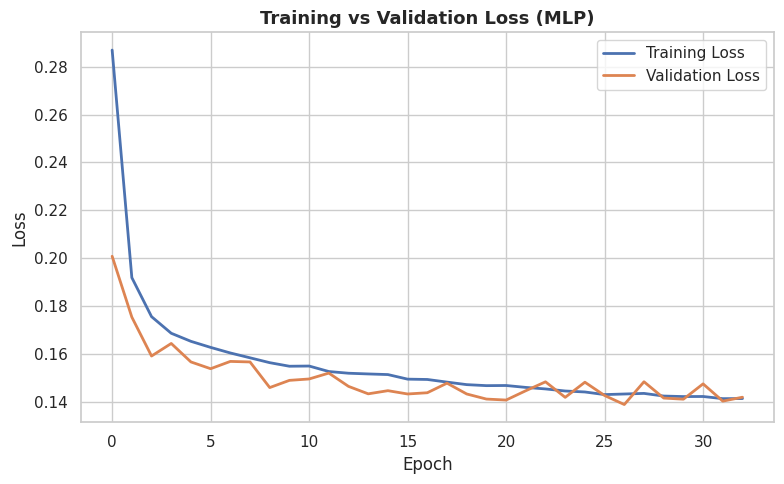

1096/1096 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step

Best MLP threshold: 0.30
2573/2573 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step

TIER-1 HYBRID AIS + PSO + MLP
Accuracy              : 0.8498
Precision             : 0.7959
Recall                : 0.9781
F1-score              : 0.8776
Balanced Accuracy     : 0.8354
Attack Detection Rate : 0.9781
False Positive Rate   : 0.3074
True Negative Rate    : 0.6926

Confusion Matrix:
[[25628 11372]
 [  993 44339]]


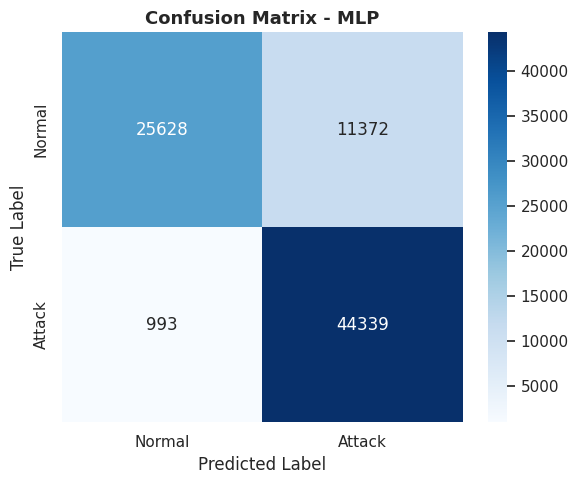

Best RF threshold : 0.34

TIER-1 HYBRID AIS + PSO + RANDOM FOREST
Accuracy              : 0.8552
Precision             : 0.7966
Recall                : 0.9897
F1-score              : 0.8827
Balanced Accuracy     : 0.8401
Attack Detection Rate : 0.9897
False Positive Rate   : 0.3096
True Negative Rate    : 0.6904

Confusion Matrix:
[[25546 11454]
 [  468 44864]]


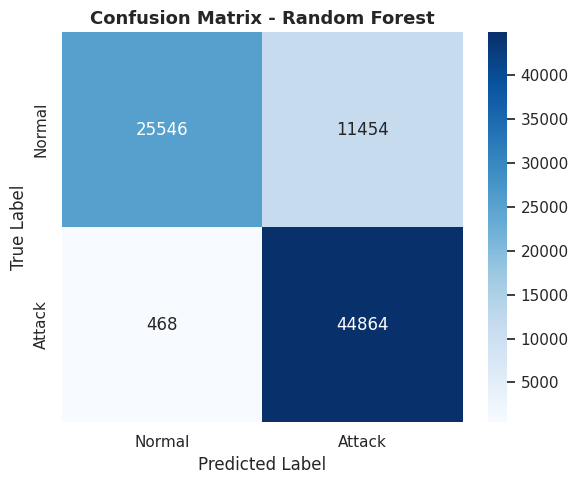

Best XGB threshold: 0.38

TIER-1 HYBRID AIS + PSO + XGBOOST
Accuracy              : 0.8652
Precision             : 0.8087
Recall                : 0.9892
F1-score              : 0.8899
Balanced Accuracy     : 0.8513
Attack Detection Rate : 0.9892
False Positive Rate   : 0.2866
True Negative Rate    : 0.7134

Confusion Matrix:
[[26395 10605]
 [  491 44841]]


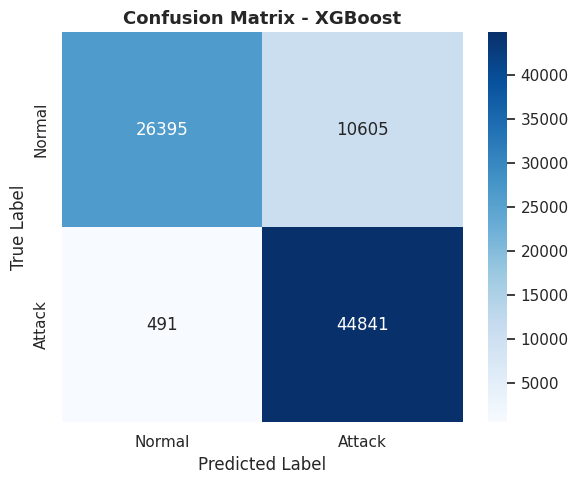


TIER-1 HYBRID AIS + PSO + ENSEMBLE VOTING
Accuracy              : 0.8591
Precision             : 0.8005
Recall                : 0.9911
F1-score              : 0.8857
Balanced Accuracy     : 0.8442
Attack Detection Rate : 0.9911
False Positive Rate   : 0.3027
True Negative Rate    : 0.6973

Confusion Matrix:
[[25800 11200]
 [  402 44930]]


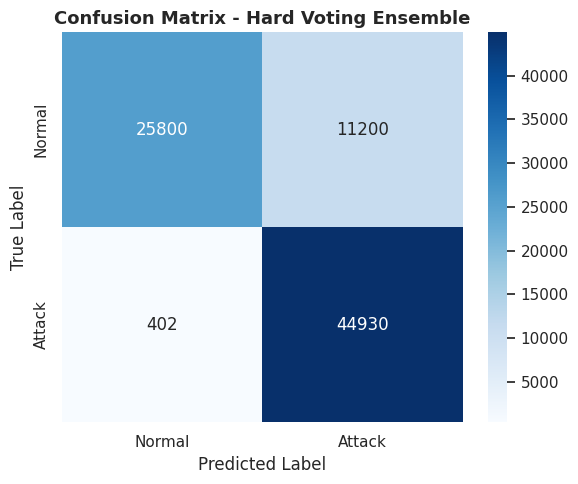


Best Soft Voting threshold: 0.38

TIER-1 HYBRID AIS + PSO + SOFT VOTING ENSEMBLE
Accuracy              : 0.8658
Precision             : 0.8090
Recall                : 0.9900
F1-score              : 0.8904
Balanced Accuracy     : 0.8518
Attack Detection Rate : 0.9900
False Positive Rate   : 0.2864
True Negative Rate    : 0.7136

Confusion Matrix:
[[26405 10595]
 [  455 44877]]


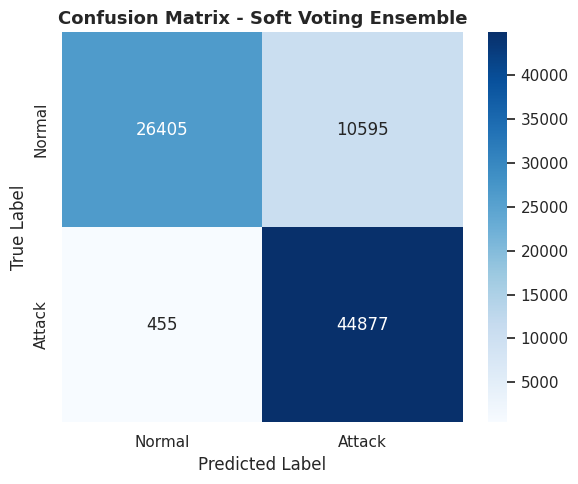

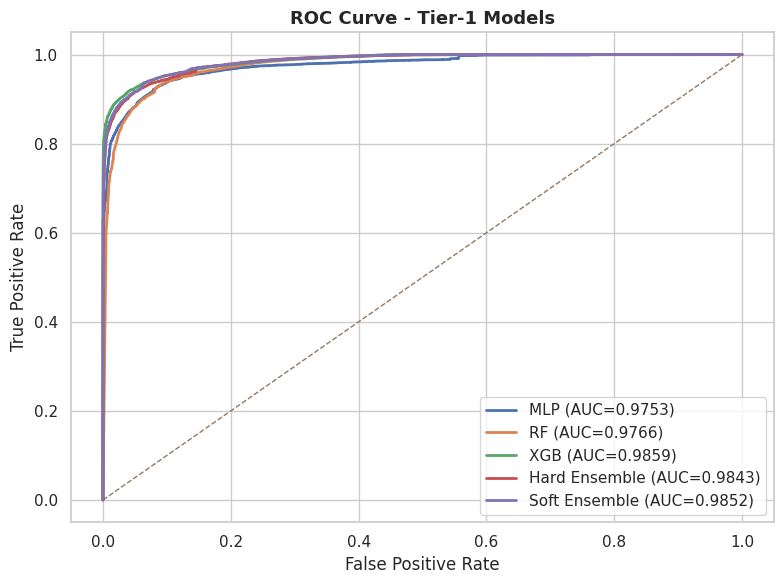

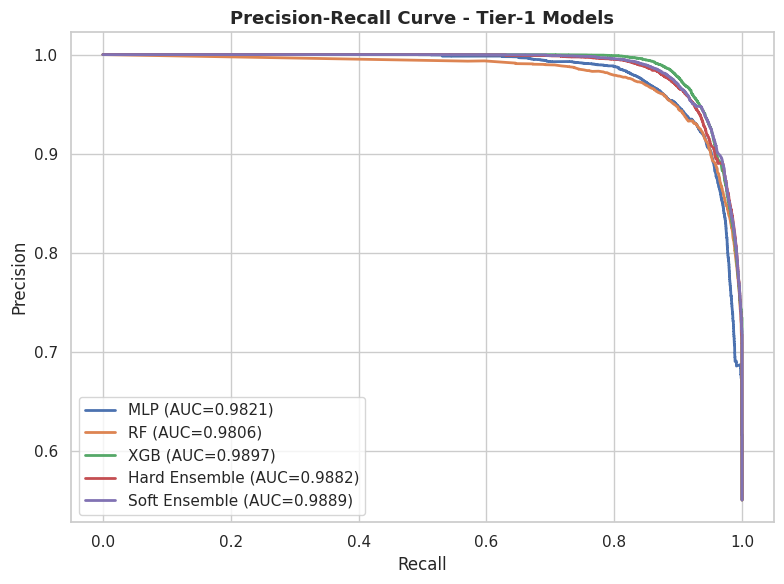

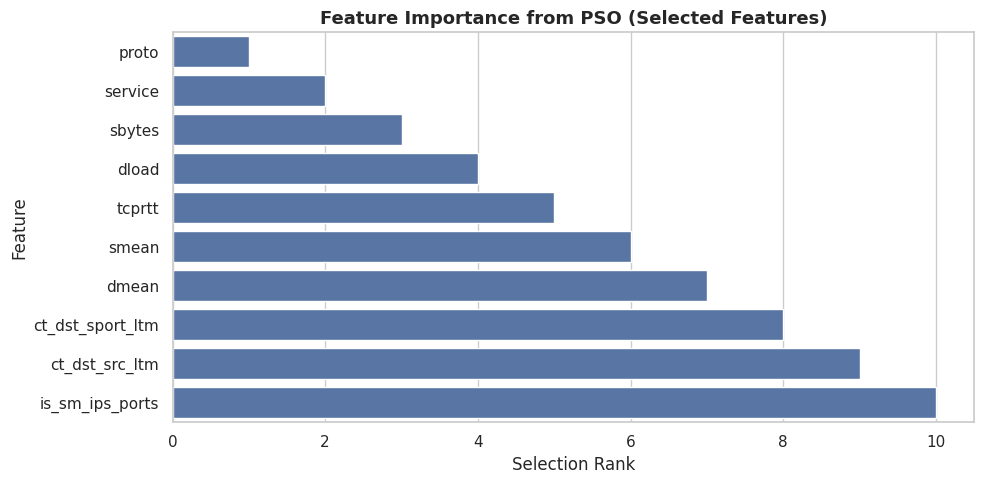

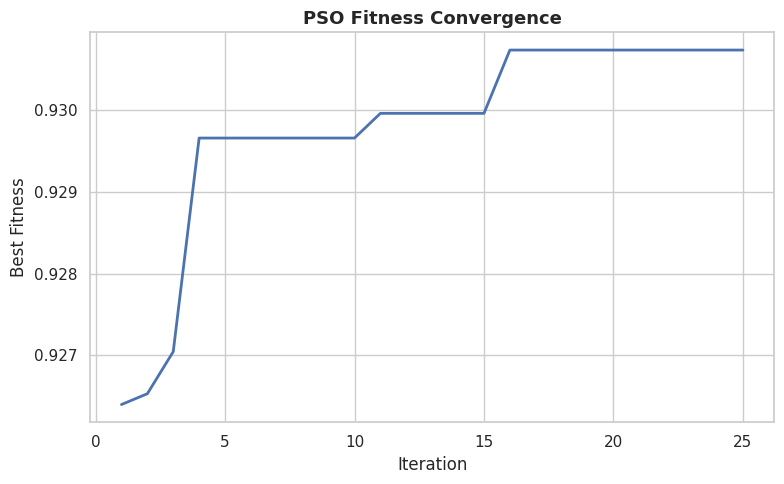


FINAL TIER-1 RESULTS SUMMARY
                  Model  Accuracy  Precision  Recall  F1-score  \
0                   MLP    0.8498     0.7959  0.9781    0.8776   
1         Random Forest    0.8552     0.7966  0.9897    0.8827   
2               XGBoost    0.8652     0.8087  0.9892    0.8899   
3  Hard Voting Ensemble    0.8591     0.8005  0.9911    0.8857   
4  Soft Voting Ensemble    0.8658     0.8090  0.9900    0.8904   

   Balanced Accuracy     ADR  False Positive Rate  True Negative Rate  \
0             0.8354  0.9781               0.3074              0.6926   
1             0.8401  0.9897               0.3096              0.6904   
2             0.8513  0.9892               0.2866              0.7134   
3             0.8442  0.9911               0.3027              0.6973   
4             0.8518  0.9900               0.2864              0.7136   

   ROC-AUC  PR-AUC  
0   0.9753  0.9821  
1   0.9766  0.9806  
2   0.9859  0.9897  
3   0.9843  0.9882  
4   0.9852  0.9889  

TIER-1 

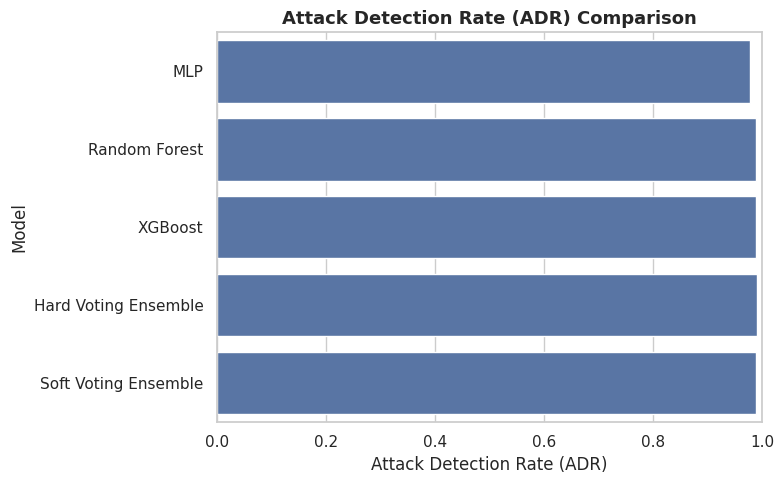


Tier-1 predicted attacks in test: 55472
Tier-1 predicted normals in test: 26860

Tier-2 train shape: (95472, 23)
Tier-2 val shape  : (23869, 23)
Tier-2 test shape : (45332, 23)

Tier-2 attack classes: ['Analysis', 'Backdoor', 'DoS', 'Exploits', 'Fuzzers', 'Generic', 'Reconnaissance', 'Shellcode', 'Worms']
Number of attack classes: 9

Applying SMOTE + Tomek on Tier-2 multiclass training set...
Class counts before SMOTETomek:
Counter({np.int64(5): 31995, np.int64(3): 26810, np.int64(4): 14510, np.int64(2): 9781, np.int64(6): 8356, np.int64(0): 1578, np.int64(1): 1432, np.int64(7): 908, np.int64(8): 102})
Using Tier-2 SMOTE k_neighbors = 5
Before SMOTETomek: (95472, 23) 95472
After  SMOTETomek: (258969, 23) 258969
Class counts after SMOTETomek:
Counter({np.int64(8): 31820, np.int64(7): 30045, np.int64(1): 29725, np.int64(0): 29547, np.int64(6): 28118, np.int64(2): 28069, np.int64(4): 27690, np.int64(3): 27028, np.int64(5): 26927})

TIER-2 MULTICLASS ATTACK CLASSIFICATION REPORT (Validati

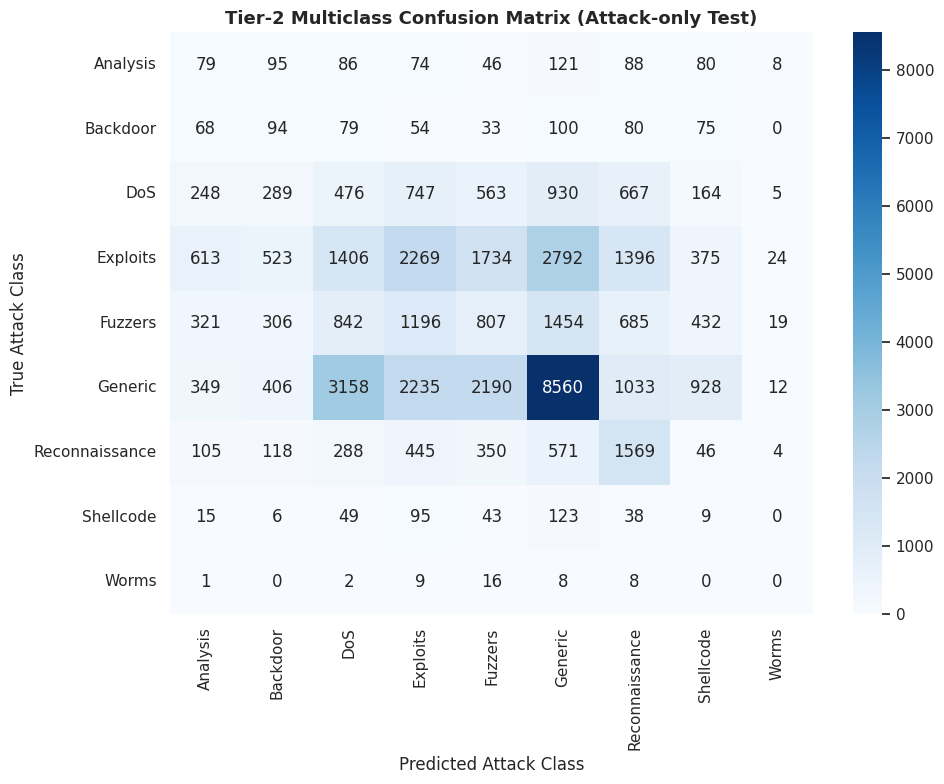


Tier-2 Accuracy   : 0.3058
Tier-2 Macro F1   : 0.1646
Tier-2 Weighted F1: 0.3287

Final two-tier predictions created successfully.

FINAL TWO-TIER MULTICLASS CLASSIFICATION REPORT (WHOLE TEST SET)
                precision    recall  f1-score   support

      Analysis       0.04      0.12      0.05       677
      Backdoor       0.04      0.16      0.07       583
           DoS       0.06      0.12      0.08      4089
      Exploits       0.24      0.20      0.22     11132
       Fuzzers       0.10      0.13      0.11      6062
       Generic       0.50      0.45      0.48     18871
        Normal       0.98      0.71      0.83     37000
Reconnaissance       0.23      0.45      0.30      3496
     Shellcode       0.00      0.02      0.01       378
         Worms       0.00      0.00      0.00        44

      accuracy                           0.49     82332
     macro avg       0.22      0.24      0.21     82332
  weighted avg       0.61      0.49      0.54     82332



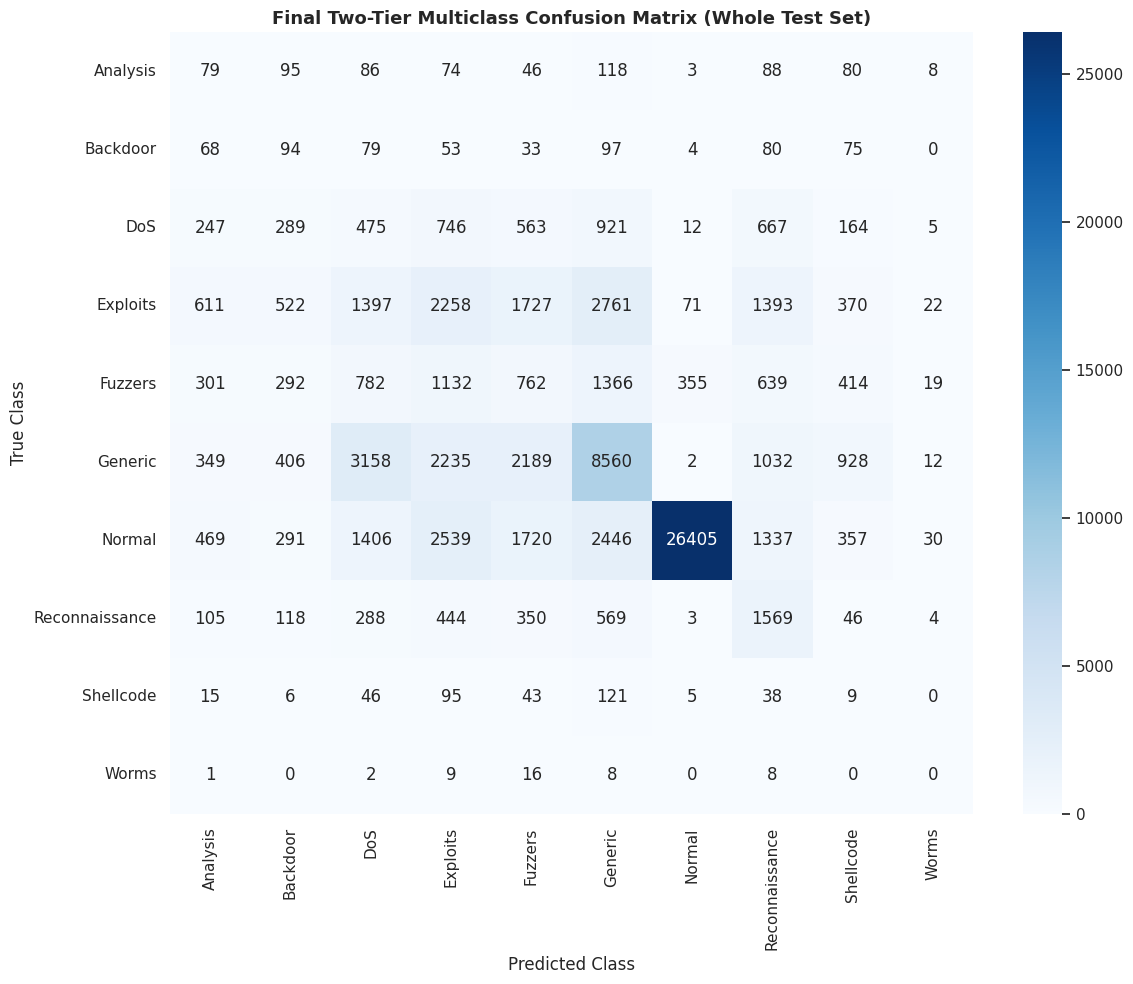


Final Two-Tier Multiclass Accuracy   : 0.4884
Final Two-Tier Multiclass Macro F1   : 0.2149
Final Two-Tier Multiclass Weighted F1: 0.5368

PER-CLASS TWO-TIER MULTICLASS SUMMARY
            Class  Precision  Recall  F1-score  Support
0        Analysis     0.0352  0.1167    0.0541    677.0
1        Backdoor     0.0445  0.1612    0.0697    583.0
2             DoS     0.0615  0.1162    0.0805   4089.0
3        Exploits     0.2356  0.2028    0.2180  11132.0
4         Fuzzers     0.1023  0.1257    0.1128   6062.0
5         Generic     0.5045  0.4536    0.4777  18871.0
6          Normal     0.9831  0.7136    0.8270  37000.0
7  Reconnaissance     0.2290  0.4488    0.3033   3496.0
8       Shellcode     0.0037  0.0238    0.0064    378.0
9           Worms     0.0000  0.0000    0.0000     44.0

Saved files:
/content/hybrid_ids_outputs_unsw_nb15_multiclass_two_tier/hybrid_selected_features.csv
/content/hybrid_ids_outputs_unsw_nb15_multiclass_two_tier/train_ais_scores.csv
/content/hybrid_ids_output

In [6]:
# =========================================================
# Step 4: Basic Cleaning for UNSW-NB15
# =========================================================
optional_drop_cols = ['id']
for col in optional_drop_cols:
    if col in train_df.columns:
        train_df = train_df.drop(columns=[col])
    if col in test_df.columns:
        test_df = test_df.drop(columns=[col])

if 'label' not in train_df.columns or 'label' not in test_df.columns:
    raise ValueError("UNSW-NB15 dataset must contain a 'label' column.")

if 'attack_cat' not in train_df.columns or 'attack_cat' not in test_df.columns:
    raise ValueError("UNSW-NB15 dataset must contain an 'attack_cat' column for multiclass classification.")

train_df['label'] = pd.to_numeric(train_df['label'], errors='coerce')
test_df['label'] = pd.to_numeric(test_df['label'], errors='coerce')

train_df = train_df.dropna(subset=['label']).reset_index(drop=True)
test_df = test_df.dropna(subset=['label']).reset_index(drop=True)

train_df['label'] = train_df['label'].astype(int)
test_df['label'] = test_df['label'].astype(int)

# Binary label
train_df['binary_label'] = train_df['label']
test_df['binary_label'] = test_df['label']

# Clean attack category
train_df['attack_cat'] = train_df['attack_cat'].astype(str).str.strip()
test_df['attack_cat'] = test_df['attack_cat'].astype(str).str.strip()

# Force normal label consistency
train_df.loc[train_df['binary_label'] == 0, 'attack_cat'] = 'Normal'
test_df.loc[test_df['binary_label'] == 0, 'attack_cat'] = 'Normal'

print("\nTrain binary distribution:")
print(train_df['binary_label'].value_counts())

print("\nTest binary distribution:")
print(test_df['binary_label'].value_counts())

print("\nTrain attack_cat distribution:")
print(train_df['attack_cat'].value_counts())

# =========================================================
# Step 5: Encode Categorical Features
# =========================================================
categorical_cols = ['proto', 'service', 'state']
existing_cat_cols = [col for col in categorical_cols if col in train_df.columns]

combined_df = pd.concat(
    [train_df.drop(columns=[]), test_df.drop(columns=[])],
    axis=0
).reset_index(drop=True)

for col in existing_cat_cols:
    le = LabelEncoder()
    combined_df[col] = le.fit_transform(combined_df[col].astype(str))

train_processed = combined_df.iloc[:len(train_df)].copy()
test_processed = combined_df.iloc[len(train_df):].copy()

# =========================================================
# Step 6: Separate Features and Labels
# =========================================================
feature_drop_cols = ['label', 'binary_label', 'attack_cat']

X_train_full = train_processed.drop(columns=feature_drop_cols)
X_test_full = test_processed.drop(columns=feature_drop_cols)

y_train_binary_full = train_df['binary_label'].values
y_test_binary = test_df['binary_label'].values

y_train_attackcat_full = train_df['attack_cat'].values
y_test_attackcat = test_df['attack_cat'].values

X_train_full = X_train_full.select_dtypes(include=[np.number]).copy()
X_test_full = X_test_full.select_dtypes(include=[np.number]).copy()

# =========================================================
# Step 6.1: Remove Infinite and Missing Values
# =========================================================
X_train_full = X_train_full.replace([np.inf, -np.inf], np.nan)
X_test_full = X_test_full.replace([np.inf, -np.inf], np.nan)

train_mask = ~X_train_full.isna().any(axis=1)
test_mask = ~X_test_full.isna().any(axis=1)

X_train_full = X_train_full[train_mask]
y_train_binary_full = y_train_binary_full[train_mask]
y_train_attackcat_full = y_train_attackcat_full[train_mask]

X_test_full = X_test_full[test_mask]
y_test_binary = y_test_binary[test_mask]
y_test_attackcat = y_test_attackcat[test_mask]

# =========================================================
# Step 7: Standardization (Z-score)
# =========================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test_full)

X_train_full = pd.DataFrame(X_train_scaled, columns=X_train_full.columns)
X_test_full = pd.DataFrame(X_test_scaled, columns=X_test_full.columns)

# =========================================================
# Step 8: Train / Validation Split
# =========================================================
X_train, X_val, y_train_binary, y_val_binary, y_train_attackcat, y_val_attackcat = train_test_split(
    X_train_full,
    y_train_binary_full,
    y_train_attackcat_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_binary_full
)

X_train = X_train.reset_index(drop=True)
X_val = X_val.reset_index(drop=True)
X_test_full = X_test_full.reset_index(drop=True)

y_train_binary = np.asarray(y_train_binary)
y_val_binary = np.asarray(y_val_binary)
y_test_binary = np.asarray(y_test_binary)

y_train_attackcat = np.asarray(y_train_attackcat)
y_val_attackcat = np.asarray(y_val_attackcat)
y_test_attackcat = np.asarray(y_test_attackcat)

print("\nTrain:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test_full.shape)

# =========================================================
# Step 8.5: Apply SMOTE + Tomek Links on Tier-1 Binary Training Set
# =========================================================
print("\nApplying SMOTE + Tomek Links on Tier-1 training set...")

class_counts = Counter(y_train_binary)
print("Class counts before SMOTETomek:")
print(class_counts)

min_class_size = min(class_counts.values())

if min_class_size < 2:
    raise ValueError(
        f"At least one class has only {min_class_size} sample. "
        f"SMOTE cannot work. Remove ultra-rare classes first."
    )

safe_k_neighbors = min(5, min_class_size - 1)
print("Using SMOTE k_neighbors =", safe_k_neighbors)

smote = SMOTE(
    k_neighbors=safe_k_neighbors,
    random_state=42
)

smote_tomek = SMOTETomek(
    smote=smote,
    random_state=42
)

X_train_res, y_train_binary_res = smote_tomek.fit_resample(X_train, y_train_binary)

print("Before SMOTETomek:", X_train.shape, len(y_train_binary))
print("After  SMOTETomek:", X_train_res.shape, len(y_train_binary_res))
print("Class counts after SMOTETomek:")
print(Counter(y_train_binary_res))

X_train = pd.DataFrame(X_train_res, columns=X_train.columns)
y_train_binary = np.asarray(y_train_binary_res)

# =========================================================
# Step 9: Balanced Subset for PSO (Tier-1 Binary)
# =========================================================
def create_balanced_subset(X, y, samples_per_class=4000):
    normal_idx = np.where(y == 0)[0]
    attack_idx = np.where(y == 1)[0]

    n_normal = min(len(normal_idx), samples_per_class)
    n_attack = min(len(attack_idx), samples_per_class)

    chosen_normal = np.random.choice(normal_idx, n_normal, replace=False)
    chosen_attack = np.random.choice(attack_idx, n_attack, replace=False)

    chosen_idx = np.concatenate([chosen_normal, chosen_attack])
    np.random.shuffle(chosen_idx)

    X_sub = X.iloc[chosen_idx].reset_index(drop=True)
    y_sub = y[chosen_idx]
    return X_sub, y_sub

X_pso, y_pso = create_balanced_subset(X_train, y_train_binary, samples_per_class=4000)

# =========================================================
# Step 10: PSO Feature Selection using RF Fitness
# =========================================================
X_pso_np = X_pso.values
X_val_np = X_val.values

def fitness_function(particle, X_train_sub, X_val_full, y_train_sub, y_val, alpha=0.97):
    selected = np.where(particle == 1)[0]

    if len(selected) == 0:
        return 0.0

    Xtr = X_train_sub[:, selected]
    Xv = X_val_full[:, selected]

    clf = RandomForestClassifier(
        n_estimators=120,
        random_state=42,
        n_jobs=-1
    )
    clf.fit(Xtr, y_train_sub)
    preds = clf.predict(Xv)

    bal_acc = balanced_accuracy_score(y_val, preds)
    feature_ratio = len(selected) / X_train_sub.shape[1]
    fitness = alpha * bal_acc + (1 - alpha) * (1 - feature_ratio)
    return fitness

num_features = X_pso_np.shape[1]
num_particles = 20
num_iterations = 25
w, c1, c2 = 0.72, 1.49, 1.49

particles = np.random.randint(0, 2, size=(num_particles, num_features))
velocities = np.random.uniform(-1, 1, size=(num_particles, num_features))

for i in range(num_particles):
    if particles[i].sum() == 0:
        particles[i, np.random.randint(0, num_features)] = 1

pbest_positions = particles.copy()
pbest_scores = np.zeros(num_particles)
gbest_position = None
gbest_score = -1
gbest_history = []

for i in range(num_particles):
    score = fitness_function(particles[i], X_pso_np, X_val_np, y_pso, y_val_binary)
    pbest_scores[i] = score
    if score > gbest_score:
        gbest_score = score
        gbest_position = particles[i].copy()

print("\nStarting PSO...")
for iteration in range(num_iterations):
    for i in range(num_particles):
        r1 = np.random.rand(num_features)
        r2 = np.random.rand(num_features)

        velocities[i] = (
            w * velocities[i]
            + c1 * r1 * (pbest_positions[i] - particles[i])
            + c2 * r2 * (gbest_position - particles[i])
        )

        sigmoid = 1 / (1 + np.exp(-velocities[i]))
        particles[i] = (np.random.rand(num_features) < sigmoid).astype(int)

        if particles[i].sum() == 0:
            particles[i, np.random.randint(0, num_features)] = 1

        score = fitness_function(particles[i], X_pso_np, X_val_np, y_pso, y_val_binary)

        if score > pbest_scores[i]:
            pbest_scores[i] = score
            pbest_positions[i] = particles[i].copy()

        if score > gbest_score:
            gbest_score = score
            gbest_position = particles[i].copy()

    gbest_history.append(gbest_score)
    print(f"Iteration {iteration + 1}/{num_iterations}, Best Fitness: {gbest_score:.4f}")

selected_feature_indices = np.where(gbest_position == 1)[0]
selected_feature_names = X_train.columns[selected_feature_indices]

print("\nSelected feature count:", len(selected_feature_indices))
print("Selected features:", list(selected_feature_names))

X_train_sel = X_train.values[:, selected_feature_indices]
X_val_sel = X_val.values[:, selected_feature_indices]
X_test_sel = X_test_full.values[:, selected_feature_indices]

# =========================================================
# Step 11: Balanced AIS Training Data
# =========================================================
def create_balanced_numpy_subset(X, y, normal_count=5000, attack_count=5000):
    normal_idx = np.where(y == 0)[0]
    attack_idx = np.where(y == 1)[0]

    n_normal = min(len(normal_idx), normal_count)
    n_attack = min(len(attack_idx), attack_count)

    chosen_normal = np.random.choice(normal_idx, n_normal, replace=False)
    chosen_attack = np.random.choice(attack_idx, n_attack, replace=False)

    return X[chosen_normal], X[chosen_attack]

self_samples, attack_samples = create_balanced_numpy_subset(
    X_train_sel, y_train_binary, normal_count=5000, attack_count=5000
)

print("\nSelf samples :", self_samples.shape)
print("Attack samples:", attack_samples.shape)

# =========================================================
# Step 12: Negative Selection Detector Generation
# =========================================================
def generate_attack_detectors(self_samples, attack_samples, num_detectors=600, min_self_distance=0.6):
    detectors = []
    attempts = 0
    max_attempts = num_detectors * 100

    while len(detectors) < num_detectors and attempts < max_attempts:
        base = attack_samples[np.random.randint(0, len(attack_samples))].copy()
        candidate = base + np.random.normal(0, 0.08, size=base.shape)

        d_self = np.min(np.linalg.norm(self_samples - candidate, axis=1))

        if d_self >= min_self_distance:
            detectors.append(candidate)

        attempts += 1

    return np.array(detectors)

detectors = generate_attack_detectors(
    self_samples=self_samples,
    attack_samples=attack_samples,
    num_detectors=1000,
    min_self_distance=0.6
)

print("\nDetector shape:", detectors.shape)

# =========================================================
# Step 13: Create AIS Anomaly Features
# =========================================================
def create_ais_scores(X, detectors):
    feature_list = []

    for sample in X:
        dists = np.linalg.norm(detectors - sample, axis=1)
        sorted_dists = np.sort(dists)

        min_dist = np.min(dists)
        mean_dist = np.mean(dists)
        std_dist = np.std(dists)
        median_dist = np.median(dists)

        closest3_mean = np.mean(sorted_dists[:3]) if len(sorted_dists) >= 3 else np.mean(sorted_dists)
        closest5_mean = np.mean(sorted_dists[:5]) if len(sorted_dists) >= 5 else np.mean(sorted_dists)
        closest10_mean = np.mean(sorted_dists[:10]) if len(sorted_dists) >= 10 else np.mean(sorted_dists)

        activated_08 = np.sum(dists <= 0.8)
        activated_10 = np.sum(dists <= 1.0)
        activated_15 = np.sum(dists <= 1.5)

        affinities = 1 / (1 + dists)
        max_affinity = np.max(affinities)
        mean_affinity = np.mean(affinities)
        std_affinity = np.std(affinities)

        feature_list.append([
            min_dist,
            mean_dist,
            std_dist,
            median_dist,
            closest3_mean,
            closest5_mean,
            closest10_mean,
            activated_08,
            activated_10,
            activated_15,
            max_affinity,
            mean_affinity,
            std_affinity
        ])

    return np.array(feature_list)

X_train_ais = create_ais_scores(X_train_sel, detectors)
X_val_ais = create_ais_scores(X_val_sel, detectors)
X_test_ais = create_ais_scores(X_test_sel, detectors)

print("\nAIS feature shape (train):", X_train_ais.shape)

# =========================================================
# Step 14: Merge Selected Features + AIS Features
# =========================================================
X_train_hybrid = np.hstack((X_train_sel, X_train_ais))
X_val_hybrid = np.hstack((X_val_sel, X_val_ais))
X_test_hybrid = np.hstack((X_test_sel, X_test_ais))

print("Hybrid train shape:", X_train_hybrid.shape)
print("Hybrid val shape  :", X_val_hybrid.shape)
print("Hybrid test shape :", X_test_hybrid.shape)

# =========================================================
# Step 15: Evaluation + Visualization Helpers
# =========================================================
results_summary = []

def compute_binary_metrics(y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    bal_acc = balanced_accuracy_score(y_true, y_pred)

    fpr = FP / (FP + TN) if (FP + TN) > 0 else 0
    tnr = TN / (TN + FP) if (TN + FP) > 0 else 0
    adr = TP / (TP + FN) if (TP + FN) > 0 else 0

    fpr_curve, tpr_curve, _ = roc_curve(y_true, y_prob)
    roc_auc = auc(fpr_curve, tpr_curve)

    precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)
    pr_auc = auc(recall_curve, precision_curve)

    return {
        'cm': cm,
        'TN': TN, 'FP': FP, 'FN': FN, 'TP': TP,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'balanced_accuracy': bal_acc,
        'fpr': fpr,
        'tnr': tnr,
        'adr': adr,
        'roc_fpr': fpr_curve,
        'roc_tpr': tpr_curve,
        'roc_auc': roc_auc,
        'pr_precision': precision_curve,
        'pr_recall': recall_curve,
        'pr_auc': pr_auc
    }

def print_binary_metrics(name, metrics_dict):
    print(f"\n{'='*70}")
    print(name)
    print(f"{'='*70}")
    print(f"Accuracy              : {metrics_dict['accuracy']:.4f}")
    print(f"Precision             : {metrics_dict['precision']:.4f}")
    print(f"Recall                : {metrics_dict['recall']:.4f}")
    print(f"F1-score              : {metrics_dict['f1']:.4f}")
    print(f"Balanced Accuracy     : {metrics_dict['balanced_accuracy']:.4f}")
    print(f"Attack Detection Rate : {metrics_dict['adr']:.4f}")
    print(f"False Positive Rate   : {metrics_dict['fpr']:.4f}")
    print(f"True Negative Rate    : {metrics_dict['tnr']:.4f}")
    print("\nConfusion Matrix:")
    print(metrics_dict['cm'])

def plot_binary_confusion_matrix(cm, title):
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Normal', 'Attack'],
        yticklabels=['Normal', 'Attack']
    )
    plt.title(title, fontsize=13, fontweight='bold')
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

def add_results_row(name, metrics_dict):
    results_summary.append({
        'Model': name,
        'Accuracy': metrics_dict['accuracy'],
        'Precision': metrics_dict['precision'],
        'Recall': metrics_dict['recall'],
        'F1-score': metrics_dict['f1'],
        'Balanced Accuracy': metrics_dict['balanced_accuracy'],
        'ADR': metrics_dict['adr'],
        'False Positive Rate': metrics_dict['fpr'],
        'True Negative Rate': metrics_dict['tnr'],
        'ROC-AUC': metrics_dict['roc_auc'],
        'PR-AUC': metrics_dict['pr_auc']
    })

# =========================================================
# Step 16: TensorFlow / GPU Stability Fix
# =========================================================
tf.keras.backend.clear_session()

X_train_hybrid = np.asarray(X_train_hybrid).astype(np.float32)
X_val_hybrid   = np.asarray(X_val_hybrid).astype(np.float32)
X_test_hybrid  = np.asarray(X_test_hybrid).astype(np.float32)

y_train_binary = np.asarray(y_train_binary).astype(np.float32)
y_val_binary   = np.asarray(y_val_binary).astype(np.float32)
y_test_binary  = np.asarray(y_test_binary).astype(np.float32)

print("X_train_hybrid dtype:", X_train_hybrid.dtype)
print("X_val_hybrid dtype  :", X_val_hybrid.dtype)
print("X_test_hybrid dtype :", X_test_hybrid.dtype)
print("y_train_binary dtype:", y_train_binary.dtype)
print("y_val_binary dtype  :", y_val_binary.dtype)
print("y_test_binary dtype :", y_test_binary.dtype)

# =========================================================
# Step 17: Train MLP (Tier-1 Binary)
# =========================================================
tf.keras.backend.clear_session()

mlp_model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_hybrid.shape[1],)),
    Dropout(0.4),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

mlp_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\nMLP MODEL SUMMARY")
mlp_model.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

history = mlp_model.fit(
    X_train_hybrid, y_train_binary,
    validation_data=(X_val_hybrid, y_val_binary),
    epochs=80,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)

# =========================================================
# Step 18: Training vs Validation Loss
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
plt.title('Training vs Validation Loss (MLP)', fontsize=13, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# Step 19: Threshold tuning for MLP
# =========================================================
mlp_val_probs = mlp_model.predict(X_val_hybrid).ravel()
candidate_thresholds = np.arange(0.30, 0.71, 0.02)

best_mlp_threshold = 0.50
best_mlp_f1 = -1

for th in candidate_thresholds:
    preds = (mlp_val_probs >= th).astype(int)
    score = f1_score(y_val_binary, preds, zero_division=0)
    if score > best_mlp_f1:
        best_mlp_f1 = score
        best_mlp_threshold = th

print(f"\nBest MLP threshold: {best_mlp_threshold:.2f}")

mlp_test_probs = mlp_model.predict(X_test_hybrid).ravel()
mlp_pred = (mlp_test_probs >= best_mlp_threshold).astype(int)

mlp_metrics = compute_binary_metrics(y_test_binary, mlp_pred, mlp_test_probs)
print_binary_metrics("TIER-1 HYBRID AIS + PSO + MLP", mlp_metrics)
plot_binary_confusion_matrix(mlp_metrics['cm'], "Confusion Matrix - MLP")
add_results_row("MLP", mlp_metrics)

# =========================================================
# Step 20: Train Random Forest (Tier-1 Binary)
# =========================================================
rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_hybrid, y_train_binary)

rf_val_probs = rf_model.predict_proba(X_val_hybrid)[:, 1]
best_rf_threshold = 0.50
best_rf_f1 = -1

for th in candidate_thresholds:
    preds = (rf_val_probs >= th).astype(int)
    score = f1_score(y_val_binary, preds, zero_division=0)
    if score > best_rf_f1:
        best_rf_f1 = score
        best_rf_threshold = th

print(f"Best RF threshold : {best_rf_threshold:.2f}")

rf_test_probs = rf_model.predict_proba(X_test_hybrid)[:, 1]
rf_pred = (rf_test_probs >= best_rf_threshold).astype(int)

rf_metrics = compute_binary_metrics(y_test_binary, rf_pred, rf_test_probs)
print_binary_metrics("TIER-1 HYBRID AIS + PSO + RANDOM FOREST", rf_metrics)
plot_binary_confusion_matrix(rf_metrics['cm'], "Confusion Matrix - Random Forest")
add_results_row("Random Forest", rf_metrics)

# =========================================================
# Step 21: Train XGBoost (Tier-1 Binary)
# =========================================================
xgb_model = XGBClassifier(
    n_estimators=900,
    max_depth=10,
    learning_rate=0.03,
    subsample=0.90,
    colsample_bytree=0.90,
    gamma=0.1,
    min_child_weight=2,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_hybrid, y_train_binary,
    eval_set=[(X_val_hybrid, y_val_binary)],
    verbose=False
)

xgb_val_probs = xgb_model.predict_proba(X_val_hybrid)[:, 1]
best_xgb_threshold = 0.50
best_xgb_f1 = -1

for th in candidate_thresholds:
    preds = (xgb_val_probs >= th).astype(int)
    score = f1_score(y_val_binary, preds, zero_division=0)
    if score > best_xgb_f1:
        best_xgb_f1 = score
        best_xgb_threshold = th

print(f"Best XGB threshold: {best_xgb_threshold:.2f}")

xgb_test_probs = xgb_model.predict_proba(X_test_hybrid)[:, 1]
xgb_pred = (xgb_test_probs >= best_xgb_threshold).astype(int)

xgb_metrics = compute_binary_metrics(y_test_binary, xgb_pred, xgb_test_probs)
print_binary_metrics("TIER-1 HYBRID AIS + PSO + XGBOOST", xgb_metrics)
plot_binary_confusion_matrix(xgb_metrics['cm'], "Confusion Matrix - XGBoost")
add_results_row("XGBoost", xgb_metrics)

# =========================================================
# Step 22: Ensemble Voting (Hard) - Tier-1 Binary
# =========================================================
ensemble_votes = mlp_pred + rf_pred + xgb_pred
ensemble_pred = (ensemble_votes >= 2).astype(int)

hard_vote_probs = (mlp_test_probs + rf_test_probs + xgb_test_probs) / 3.0

ensemble_metrics = compute_binary_metrics(y_test_binary, ensemble_pred, hard_vote_probs)
print_binary_metrics("TIER-1 HYBRID AIS + PSO + ENSEMBLE VOTING", ensemble_metrics)
plot_binary_confusion_matrix(ensemble_metrics['cm'], "Confusion Matrix - Hard Voting Ensemble")
add_results_row("Hard Voting Ensemble", ensemble_metrics)

# =========================================================
# Step 23: Soft Voting - Tier-1 Binary
# =========================================================
soft_probs = (
    0.15 * mlp_test_probs +
    0.30 * rf_test_probs +
    0.55 * xgb_test_probs
)

best_soft_threshold = 0.50
best_soft_f1 = -1

soft_val_probs = (
    0.15 * mlp_val_probs +
    0.30 * rf_val_probs +
    0.55 * xgb_val_probs
)

for th in candidate_thresholds:
    preds = (soft_val_probs >= th).astype(int)
    score = f1_score(y_val_binary, preds, zero_division=0)
    if score > best_soft_f1:
        best_soft_f1 = score
        best_soft_threshold = th

print(f"\nBest Soft Voting threshold: {best_soft_threshold:.2f}")

soft_ensemble_pred = (soft_probs >= best_soft_threshold).astype(int)

soft_metrics = compute_binary_metrics(y_test_binary, soft_ensemble_pred, soft_probs)
print_binary_metrics("TIER-1 HYBRID AIS + PSO + SOFT VOTING ENSEMBLE", soft_metrics)
plot_binary_confusion_matrix(soft_metrics['cm'], "Confusion Matrix - Soft Voting Ensemble")
add_results_row("Soft Voting Ensemble", soft_metrics)

# =========================================================
# Step 24: ROC Curve (All Tier-1 Models)
# =========================================================
plt.figure(figsize=(8, 6))
plt.plot(mlp_metrics['roc_fpr'], mlp_metrics['roc_tpr'], label=f"MLP (AUC={mlp_metrics['roc_auc']:.4f})", linewidth=2)
plt.plot(rf_metrics['roc_fpr'], rf_metrics['roc_tpr'], label=f"RF (AUC={rf_metrics['roc_auc']:.4f})", linewidth=2)
plt.plot(xgb_metrics['roc_fpr'], xgb_metrics['roc_tpr'], label=f"XGB (AUC={xgb_metrics['roc_auc']:.4f})", linewidth=2)
plt.plot(ensemble_metrics['roc_fpr'], ensemble_metrics['roc_tpr'], label=f"Hard Ensemble (AUC={ensemble_metrics['roc_auc']:.4f})", linewidth=2)
plt.plot(soft_metrics['roc_fpr'], soft_metrics['roc_tpr'], label=f"Soft Ensemble (AUC={soft_metrics['roc_auc']:.4f})", linewidth=2)
plt.plot([0, 1], [0, 1], linestyle='--', linewidth=1)
plt.title("ROC Curve - Tier-1 Models", fontsize=13, fontweight='bold')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# Step 25: Precision-Recall Curve (All Tier-1 Models)
# =========================================================
plt.figure(figsize=(8, 6))
plt.plot(mlp_metrics['pr_recall'], mlp_metrics['pr_precision'], label=f"MLP (AUC={mlp_metrics['pr_auc']:.4f})", linewidth=2)
plt.plot(rf_metrics['pr_recall'], rf_metrics['pr_precision'], label=f"RF (AUC={rf_metrics['pr_auc']:.4f})", linewidth=2)
plt.plot(xgb_metrics['pr_recall'], xgb_metrics['pr_precision'], label=f"XGB (AUC={xgb_metrics['pr_auc']:.4f})", linewidth=2)
plt.plot(ensemble_metrics['pr_recall'], ensemble_metrics['pr_precision'], label=f"Hard Ensemble (AUC={ensemble_metrics['pr_auc']:.4f})", linewidth=2)
plt.plot(soft_metrics['pr_recall'], soft_metrics['pr_precision'], label=f"Soft Ensemble (AUC={soft_metrics['pr_auc']:.4f})", linewidth=2)
plt.title("Precision-Recall Curve - Tier-1 Models", fontsize=13, fontweight='bold')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.show()

# =========================================================
# Step 26: Feature Importance from PSO
# =========================================================
selected_mask = np.zeros(num_features)
selected_mask[selected_feature_indices] = 1

pso_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Selected_by_PSO': selected_mask.astype(int)
}).sort_values(by='Selected_by_PSO', ascending=False)

top_selected_features = pd.DataFrame({
    'Feature': selected_feature_names,
    'Selection_Order': np.arange(1, len(selected_feature_names) + 1)
})

plt.figure(figsize=(10, max(5, len(selected_feature_names) * 0.25)))
sns.barplot(
    data=top_selected_features,
    y='Feature',
    x='Selection_Order',
    orient='h'
)
plt.title("Feature Importance from PSO (Selected Features)", fontsize=13, fontweight='bold')
plt.xlabel("Selection Rank")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# =========================================================
# Step 27: PSO Fitness Convergence Curve
# =========================================================
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(gbest_history) + 1), gbest_history, linewidth=2)
plt.title("PSO Fitness Convergence", fontsize=13, fontweight='bold')
plt.xlabel("Iteration")
plt.ylabel("Best Fitness")
plt.tight_layout()
plt.show()

# =========================================================
# Step 28: Tier-1 Results Summary Table
# =========================================================
results_df = pd.DataFrame(results_summary)
print("\nFINAL TIER-1 RESULTS SUMMARY")
print(results_df.round(4))

# =========================================================
# Step 29: Tier-1 Attack Detection Rate (ADR) Summary
# =========================================================
adr_summary_df = pd.DataFrame({
    'Model': results_df['Model'],
    'Attack Detection Rate (ADR)': results_df['ADR']
})

print("\n" + "="*60)
print("TIER-1 ATTACK DETECTION RATE (ADR) SUMMARY")
print("="*60)
print(adr_summary_df.round(4))

plt.figure(figsize=(8, 5))
sns.barplot(data=adr_summary_df, x='Attack Detection Rate (ADR)', y='Model')
plt.title("Attack Detection Rate (ADR) Comparison", fontsize=13, fontweight='bold')
plt.xlim(0, 1.0)
plt.tight_layout()
plt.show()

# =========================================================
# Step 30: TWO-TIER MULTICLASS PREPARATION
# Use Tier-1 Soft Voting output as final attack detector
# =========================================================
tier1_final_pred_test = soft_ensemble_pred.copy()
tier1_final_pred_val = (soft_val_probs >= best_soft_threshold).astype(int)

print("\nTier-1 predicted attacks in test:", np.sum(tier1_final_pred_test == 1))
print("Tier-1 predicted normals in test:", np.sum(tier1_final_pred_test == 0))

# =========================================================
# Step 31: Prepare Tier-2 Attack-Only Train/Val/Test
# Train Tier-2 using true attack samples only
# =========================================================
train_attack_idx = np.where(y_train_attackcat != 'Normal')[0]
val_attack_idx = np.where(y_val_attackcat != 'Normal')[0]
test_attack_idx = np.where(y_test_attackcat != 'Normal')[0]

X_train_tier2 = X_train_hybrid[train_attack_idx]
X_val_tier2 = X_val_hybrid[val_attack_idx]
X_test_tier2_all_attacks = X_test_hybrid[test_attack_idx]

y_train_tier2_labels = y_train_attackcat[train_attack_idx]
y_val_tier2_labels = y_val_attackcat[val_attack_idx]
y_test_tier2_labels = y_test_attackcat[test_attack_idx]

print("\nTier-2 train shape:", X_train_tier2.shape)
print("Tier-2 val shape  :", X_val_tier2.shape)
print("Tier-2 test shape :", X_test_tier2_all_attacks.shape)

# =========================================================
# Step 32: Encode Tier-2 Multiclass Attack Labels
# =========================================================
attack_label_encoder = LabelEncoder()
y_train_tier2 = attack_label_encoder.fit_transform(y_train_tier2_labels)
y_val_tier2 = attack_label_encoder.transform(y_val_tier2_labels)
y_test_tier2 = attack_label_encoder.transform(y_test_tier2_labels)

attack_class_names = list(attack_label_encoder.classes_)
num_attack_classes = len(attack_class_names)

print("\nTier-2 attack classes:", attack_class_names)
print("Number of attack classes:", num_attack_classes)

# =========================================================
# Step 33: Apply SMOTE + Tomek on Tier-2 Multiclass Training Set
# =========================================================
print("\nApplying SMOTE + Tomek on Tier-2 multiclass training set...")

tier2_class_counts = Counter(y_train_tier2)
print("Class counts before SMOTETomek:")
print(tier2_class_counts)

min_class_size_t2 = min(tier2_class_counts.values())

if min_class_size_t2 < 2:
    raise ValueError(
        f"At least one Tier-2 class has only {min_class_size_t2} sample. "
        f"SMOTE cannot work. Remove ultra-rare attack classes first."
    )

safe_k_neighbors_t2 = min(5, min_class_size_t2 - 1)
print("Using Tier-2 SMOTE k_neighbors =", safe_k_neighbors_t2)

smote_t2 = SMOTE(
    k_neighbors=safe_k_neighbors_t2,
    random_state=42
)

smote_tomek_t2 = SMOTETomek(
    smote=smote_t2,
    random_state=42
)

X_train_tier2_res, y_train_tier2_res = smote_tomek_t2.fit_resample(X_train_tier2, y_train_tier2)

print("Before SMOTETomek:", X_train_tier2.shape, len(y_train_tier2))
print("After  SMOTETomek:", X_train_tier2_res.shape, len(y_train_tier2_res))
print("Class counts after SMOTETomek:")
print(Counter(y_train_tier2_res))

X_train_tier2 = np.asarray(X_train_tier2_res, dtype=np.float32)
y_train_tier2 = np.asarray(y_train_tier2_res)

X_val_tier2 = np.asarray(X_val_tier2, dtype=np.float32)
X_test_tier2_all_attacks = np.asarray(X_test_tier2_all_attacks, dtype=np.float32)

# =========================================================
# Step 34: Train Tier-2 Multiclass Random Forest
# =========================================================
tier2_rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

tier2_rf_model.fit(X_train_tier2, y_train_tier2)

tier2_val_pred = tier2_rf_model.predict(X_val_tier2)
tier2_test_pred = tier2_rf_model.predict(X_test_tier2_all_attacks)

print("\n" + "="*70)
print("TIER-2 MULTICLASS ATTACK CLASSIFICATION REPORT (Validation)")
print("="*70)
print(classification_report(
    y_val_tier2,
    tier2_val_pred,
    target_names=attack_class_names,
    zero_division=0
))

print("\n" + "="*70)
print("TIER-2 MULTICLASS ATTACK CLASSIFICATION REPORT (Attack-only Test)")
print("="*70)
print(classification_report(
    y_test_tier2,
    tier2_test_pred,
    target_names=attack_class_names,
    zero_division=0
))

tier2_cm = confusion_matrix(y_test_tier2, tier2_test_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    tier2_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=attack_class_names,
    yticklabels=attack_class_names
)
plt.title("Tier-2 Multiclass Confusion Matrix (Attack-only Test)", fontsize=13, fontweight='bold')
plt.xlabel("Predicted Attack Class")
plt.ylabel("True Attack Class")
plt.tight_layout()
plt.show()

tier2_accuracy = accuracy_score(y_test_tier2, tier2_test_pred)
tier2_macro_f1 = f1_score(y_test_tier2, tier2_test_pred, average='macro', zero_division=0)
tier2_weighted_f1 = f1_score(y_test_tier2, tier2_test_pred, average='weighted', zero_division=0)

print(f"\nTier-2 Accuracy   : {tier2_accuracy:.4f}")
print(f"Tier-2 Macro F1   : {tier2_macro_f1:.4f}")
print(f"Tier-2 Weighted F1: {tier2_weighted_f1:.4f}")

# =========================================================
# Step 35: FINAL TWO-TIER PREDICTION ON WHOLE TEST SET
# Tier-1 decides Normal vs Attack
# Tier-2 assigns attack category only for predicted attacks
# =========================================================
final_two_tier_pred_labels = np.array(['Normal'] * len(X_test_hybrid), dtype=object)

predicted_attack_indices = np.where(tier1_final_pred_test == 1)[0]

if len(predicted_attack_indices) > 0:
    X_test_for_tier2 = X_test_hybrid[predicted_attack_indices]
    tier2_pred_on_tier1_attacks = tier2_rf_model.predict(X_test_for_tier2)
    tier2_pred_attack_labels = attack_label_encoder.inverse_transform(tier2_pred_on_tier1_attacks)
    final_two_tier_pred_labels[predicted_attack_indices] = tier2_pred_attack_labels

print("\nFinal two-tier predictions created successfully.")

# =========================================================
# Step 36: Final Multiclass Evaluation on Whole Test Set
# =========================================================
all_final_classes = sorted(list(set(y_test_attackcat) | set(final_two_tier_pred_labels)))

print("\n" + "="*70)
print("FINAL TWO-TIER MULTICLASS CLASSIFICATION REPORT (WHOLE TEST SET)")
print("="*70)
print(classification_report(
    y_test_attackcat,
    final_two_tier_pred_labels,
    labels=all_final_classes,
    zero_division=0
))

final_multiclass_cm = confusion_matrix(
    y_test_attackcat,
    final_two_tier_pred_labels,
    labels=all_final_classes
)

plt.figure(figsize=(12, 10))
sns.heatmap(
    final_multiclass_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=all_final_classes,
    yticklabels=all_final_classes
)
plt.title("Final Two-Tier Multiclass Confusion Matrix (Whole Test Set)", fontsize=13, fontweight='bold')
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.show()

final_mc_accuracy = accuracy_score(y_test_attackcat, final_two_tier_pred_labels)
final_mc_macro_f1 = f1_score(y_test_attackcat, final_two_tier_pred_labels, average='macro', zero_division=0)
final_mc_weighted_f1 = f1_score(y_test_attackcat, final_two_tier_pred_labels, average='weighted', zero_division=0)

print(f"\nFinal Two-Tier Multiclass Accuracy   : {final_mc_accuracy:.4f}")
print(f"Final Two-Tier Multiclass Macro F1   : {final_mc_macro_f1:.4f}")
print(f"Final Two-Tier Multiclass Weighted F1: {final_mc_weighted_f1:.4f}")

# =========================================================
# Step 37: Per-Class Attack Detection Summary
# =========================================================
final_report_dict = classification_report(
    y_test_attackcat,
    final_two_tier_pred_labels,
    labels=all_final_classes,
    output_dict=True,
    zero_division=0
)

per_class_rows = []
for cls in all_final_classes:
    if cls in final_report_dict:
        per_class_rows.append({
            'Class': cls,
            'Precision': final_report_dict[cls]['precision'],
            'Recall': final_report_dict[cls]['recall'],
            'F1-score': final_report_dict[cls]['f1-score'],
            'Support': final_report_dict[cls]['support']
        })

per_class_df = pd.DataFrame(per_class_rows)
print("\nPER-CLASS TWO-TIER MULTICLASS SUMMARY")
print(per_class_df.round(4))

# =========================================================
# Step 38: Save Results
# =========================================================
output_dir = '/content/hybrid_ids_outputs_unsw_nb15_multiclass_two_tier'
os.makedirs(output_dir, exist_ok=True)

selected_features_df = pd.DataFrame({
    "Selected_Features": selected_feature_names
})
selected_features_df.to_csv(f'{output_dir}/hybrid_selected_features.csv', index=False)

ais_feature_names = [
    'min_dist', 'mean_dist', 'std_dist', 'median_dist',
    'closest3_mean', 'closest5_mean', 'closest10_mean',
    'activated_08', 'activated_10', 'activated_15',
    'max_affinity', 'mean_affinity', 'std_affinity'
]

train_ais_df = pd.DataFrame(X_train_ais, columns=ais_feature_names)
train_ais_df.to_csv(f'{output_dir}/train_ais_scores.csv', index=False)

pred_df = pd.DataFrame({
    'True_Binary': y_test_binary.astype(int),
    'True_AttackCat': y_test_attackcat,
    'MLP_Prob': mlp_test_probs,
    'MLP_Pred': mlp_pred,
    'RF_Prob': rf_test_probs,
    'RF_Pred': rf_pred,
    'XGB_Prob': xgb_test_probs,
    'XGB_Pred': xgb_pred,
    'Hard_Ensemble_Pred': ensemble_pred,
    'Soft_Prob': soft_probs,
    'Soft_Ensemble_Pred': soft_ensemble_pred,
    'Final_Two_Tier_Pred': final_two_tier_pred_labels
})
pred_df.to_csv(f'{output_dir}/hybrid_two_tier_predictions.csv', index=False)

results_df.to_csv(f'{output_dir}/tier1_model_results_summary.csv', index=False)
adr_summary_df.to_csv(f'{output_dir}/tier1_adr_summary.csv', index=False)
pso_importance_df.to_csv(f'{output_dir}/pso_feature_importance.csv', index=False)
per_class_df.to_csv(f'{output_dir}/final_two_tier_per_class_summary.csv', index=False)

print("\nSaved files:")
print(f"{output_dir}/hybrid_selected_features.csv")
print(f"{output_dir}/train_ais_scores.csv")
print(f"{output_dir}/hybrid_two_tier_predictions.csv")
print(f"{output_dir}/tier1_model_results_summary.csv")
print(f"{output_dir}/tier1_adr_summary.csv")
print(f"{output_dir}/pso_feature_importance.csv")
print(f"{output_dir}/final_two_tier_per_class_summary.csv")